In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE



df = pd.read_csv('dataset/cars_classification_dataset.csv')
df.head()

,buying,maint,doors,persons,lug_boot,safety,car
0,vhigh,vhigh,two,two,small,low,unacc
1,vhigh,vhigh,two,two,small,med,unacc
2,vhigh,vhigh,two,two,small,high,unacc
3,vhigh,vhigh,two,two,med,low,unacc
4,vhigh,vhigh,two,two,med,med,unacc


In [ ]:
df.describe()
# df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   car       1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


In [ ]:
# df.isnull().sum()
# df.isnull().values.any()
df.isnull().sum() / len(df) * 100

buying      0.0
maint       0.0
doors       0.0
persons     0.0
lug_boot    0.0
safety      0.0
car         0.0
dtype: float64

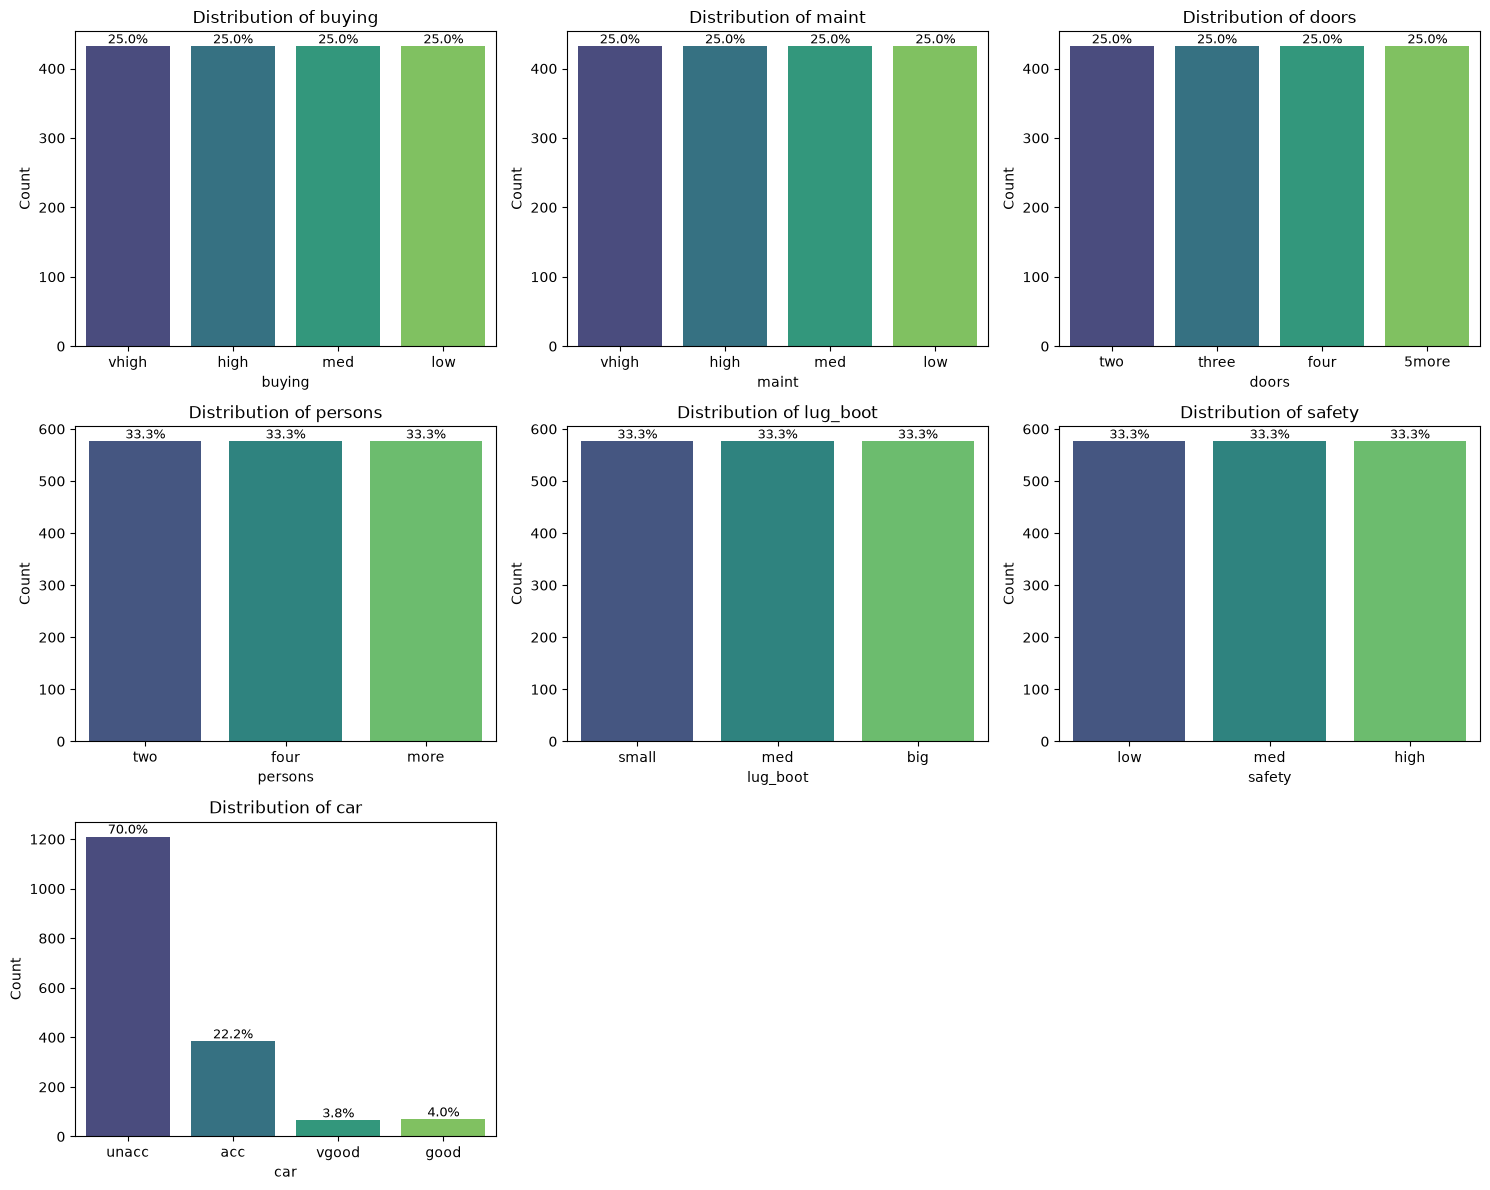

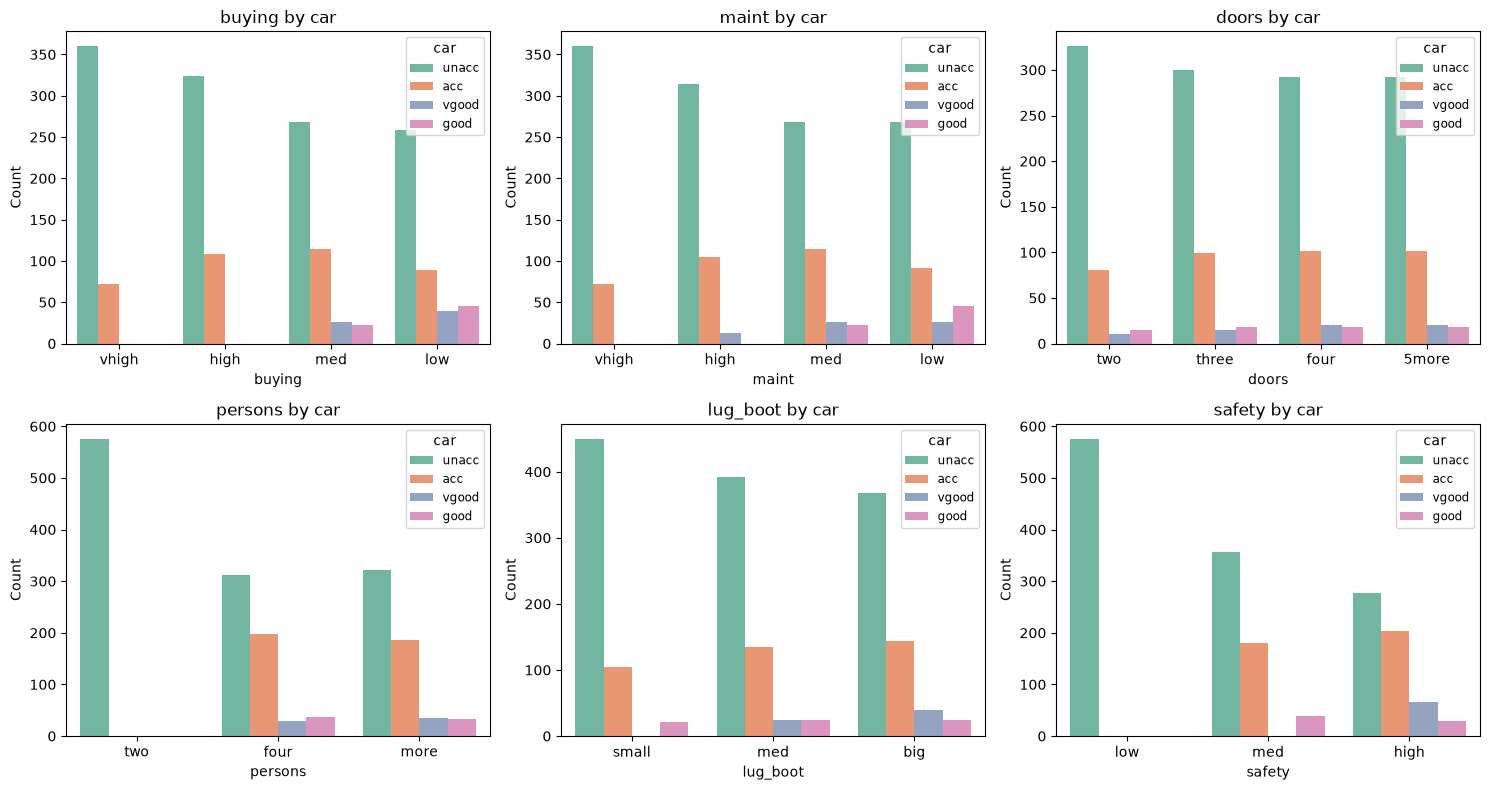

In [ ]:
target_column = 'car'
all_columns = df.columns
categorical_features = df.columns.drop(target_column)

cols_per_row = 3
num_rows_uni = math.ceil(len(all_columns) / cols_per_row)

# Create a grid of subplots
fig_uni, axes_uni = plt.subplots(num_rows_uni, cols_per_row, figsize=(15, 4 * num_rows_uni))
axes_uni = axes_uni.flatten()

for i, col in enumerate(all_columns):
    ax = axes_uni[i]
    
    sns.countplot(data=df, x=col, hue=col, palette="viridis", legend=False, ax=ax)
    
    ax.set_title(f"Distribution of {col}")
    ax.set_ylabel("Count")
    
    total = len(df[col])
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            x_position = p.get_x() + p.get_width() / 2
            y_position = height
            ax.annotate(percentage, (x_position, y_position), ha='center', va='bottom', fontsize=9)

# Hide any empty subplots
for j in range(i + 1, len(axes_uni)):
    axes_uni[j].set_visible(False)

plt.tight_layout()
plt.show()

num_rows_biv = math.ceil(len(categorical_features) / cols_per_row)

fig_biv, axes_biv = plt.subplots(num_rows_biv, cols_per_row, figsize=(15, 4 * num_rows_biv))
axes_biv = axes_biv.flatten()

for i, col in enumerate(categorical_features):
    ax = axes_biv[i]

    sns.countplot(data=df, x=col, hue=target_column, palette="Set2", ax=ax)
    
    ax.set_title(f"{col} by {target_column}")
    ax.set_ylabel("Count")
    ax.legend(title=target_column, loc='upper right', fontsize='small')

# Hide any empty subplots
for j in range(i + 1, len(axes_biv)):
    axes_biv[j].set_visible(False)

plt.tight_layout()
plt.show()

The initial exploration of the dataset reveals a major problem with class imbalance. 70 percent of the data belongs to a single category, the unacceptable class. If we train a model on this dataset exactly as it is, the algorithm will likely take the easy route and predict unacceptable for almost every car. This will artificially inflate the accuracy score, but the model will be completely useless for identifying good or very good cars. The data also shows strict dealbreakers, where features like a two-person capacity or low safety immediately force a car into the unacceptable category regardless of any other factors. Before moving forward with model training, we will need to address this imbalance so the algorithm can properly learn the patterns of the minority classes.

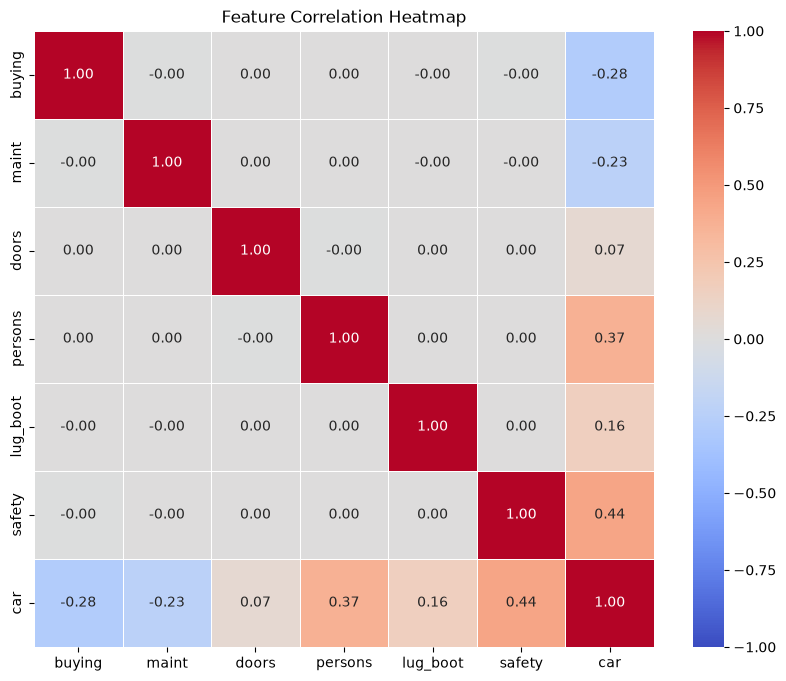

In [ ]:
# Define mapping dictionaries for ordinal encoding
buying_maint_map = {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4}
doors_map = {'two': 2, 'three': 3, 'four': 4, '5more': 5}
persons_map = {'two': 2, 'four': 4, 'more': 5}
lug_boot_map = {'small': 1, 'med': 2, 'big': 3}
safety_map = {'low': 1, 'med': 2, 'high': 3}
target_map = {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}

df_encoded = df.copy()

df_encoded['buying'] = df_encoded['buying'].map(buying_maint_map)
df_encoded['maint'] = df_encoded['maint'].map(buying_maint_map)
df_encoded['doors'] = df_encoded['doors'].map(doors_map)
df_encoded['persons'] = df_encoded['persons'].map(persons_map)
df_encoded['lug_boot'] = df_encoded['lug_boot'].map(lug_boot_map)
df_encoded['safety'] = df_encoded['safety'].map(safety_map)
df_encoded['car'] = df_encoded['car'].map(target_map)

correlation_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)
plt.title('Feature Correlation Heatmap')
plt.show()

The heatmap displays a correlation of exactly zero between all the independent features and only weak to moderate correlations with the target variable. The matrix only measures straight linear relationships, but our dataset relies on strict conditional rules, like a specific safety rating instantly making a car unacceptable regardless of other factors. The zero correlation between the features simply means they are completely independent of each other with no overlapping information, which is actually a positive thing. We should not discard any features based on this heatmap because they are still highly valuable for machine learning models that can understand these complex non-linear patterns.

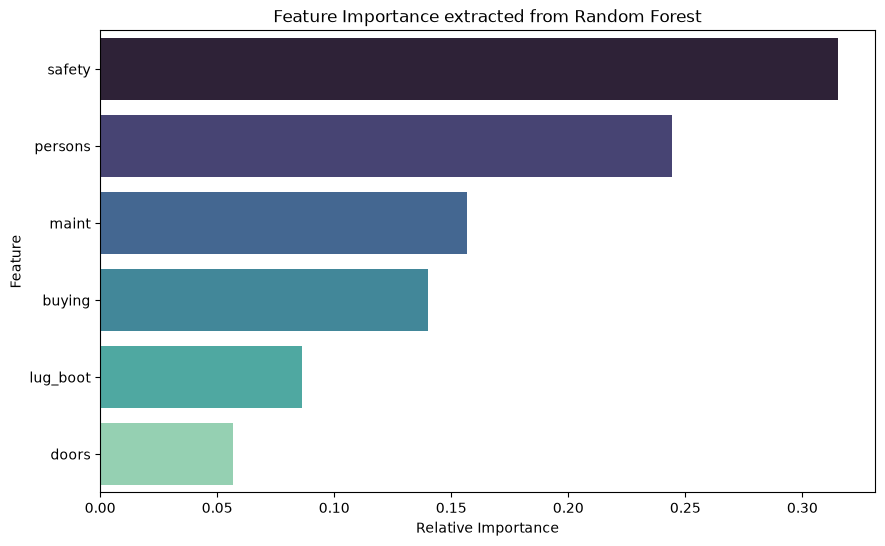

In [ ]:
X_encoded = df_encoded.drop('car', axis=1)
y_encoded = df_encoded['car']

# Train a basic Random Forest to evaluate feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_encoded, y_encoded)

# Create a dataframe for visualization
feature_importances = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
# Codul corectat
sns.barplot(
    data=feature_importances, 
    x='Importance', 
    y='Feature', 
    hue='Feature',      
    palette='mako', 
    legend=False        
)
plt.title('Feature Importance extracted from Random Forest')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

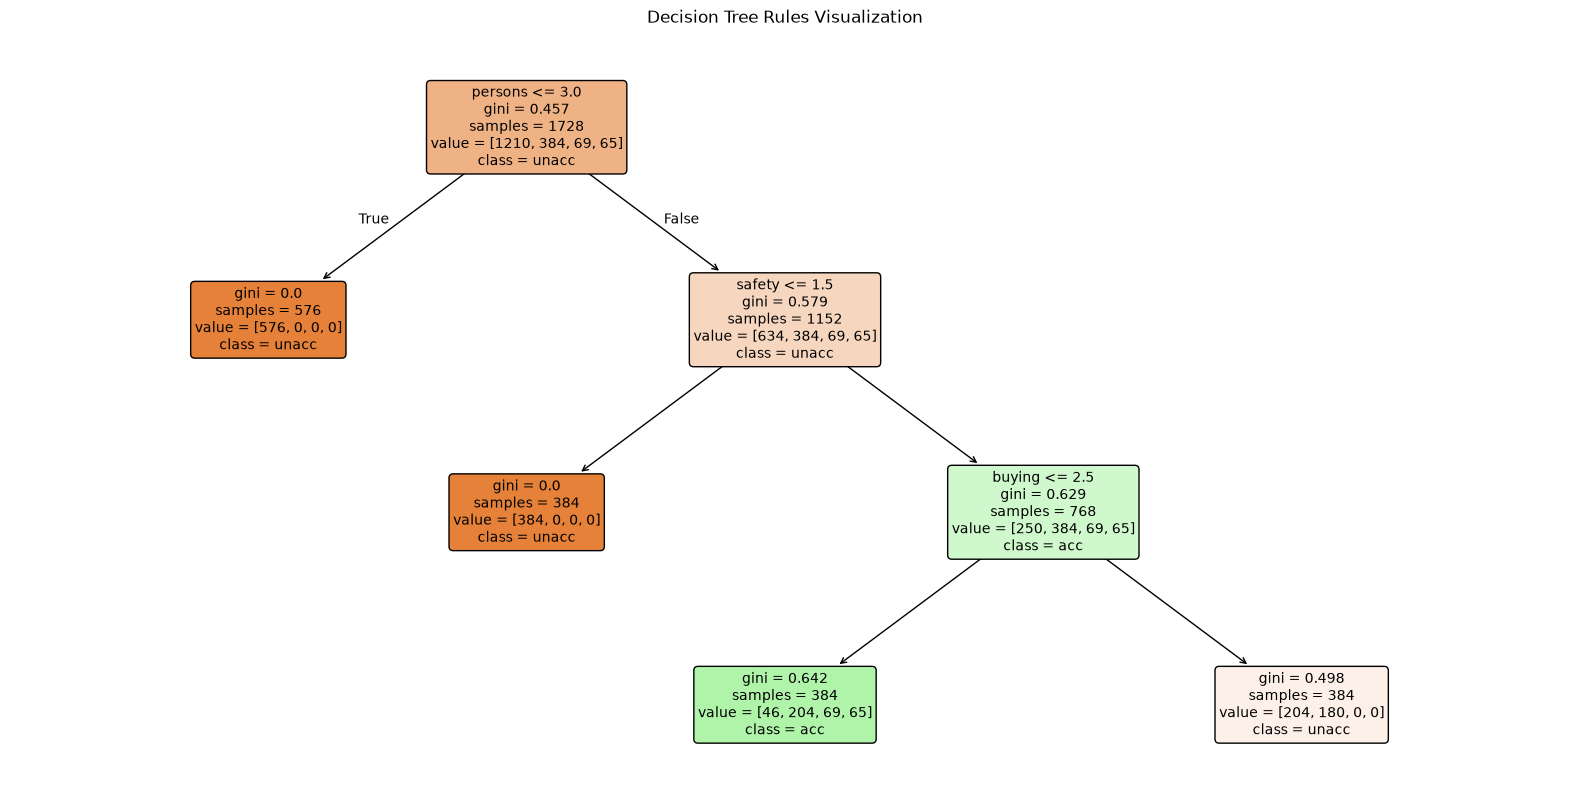

In [ ]:

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_encoded, y_encoded)

# Visualize the rules learned by the tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, 
    feature_names=X_encoded.columns, 
    class_names=['unacc', 'acc', 'good', 'vgood'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title('Decision Tree Rules Visualization')
plt.show()

The decision tree visualization confirms that the algorithm relies on strict absolute rules to filter out the majority of the data. It immediately drops any car with a two-person capacity or low safety rating into the unacceptable category with perfect certainty. The core problem highlighted by this tree is how the model struggles after these obvious filters are applied. When it finally has to evaluate the remaining cars to find the acceptable or good ones, the internal nodes show a high level of class mixture and uncertainty. This proves that while the model is highly efficient at rejecting bad cars based on simple dealbreakers, the severe lack of minority class data prevents it from learning the complex patterns required to accurately identify higher quality vehicles. Because the current data structure forces the model to memorize limitations rather than learn positive qualities, the necessary course of action is to balance the dataset synthetically so the algorithm has enough examples to properly study the minority classes.

In [21]:
X = df_encoded.drop('car', axis=1)
y = df_encoded['car']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Verify the class distribution in the training set before applying SMOTE
print("Class distribution in y_train before SMOTE:")
print(y_train.value_counts(normalize=True))

Class distribution in y_train before SMOTE:
car
0    0.700434
1    0.222142
2    0.039797
3    0.037627
Name: proportion, dtype: float64


In [ ]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Document the new proportions mathematically
print("Class distribution in y_train_resampled AFTER SMOTE:")
print(y_train_resampled.value_counts(normalize=True))


Class distribution in y_train_resampled AFTER SMOTE:
car
1    0.25
0    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64
